# Real exercises: Data Capture

Use this notebook to record exercise (pull ups, dips, 90° push ups, front level pulls, etc.) data at the gym. Optionally record myself orthogonally to understand everything better.

## Setup

In [ ]:
# Run in case of ModuleNotFoundError:
# cd ./signal-utils
# pip install -e .

from signal_utils import IMUSampleReceiver
import numpy as np
import matplotlib.pyplot as plt


def plotRawData(seq: np.ndarray, f: np.ndarray, w: np.ndarray) -> None:
    if seq.size == 0:
        print("No samples available to plot")
        return

    fig, axes = plt.subplots(4, 2, figsize=(12, 8))

    lowerBoundAccel = min(np.min(f[:, 0]), np.min(f[:, 1]), np.min(f[:, 2]))
    upperBoundAccel = max(np.max(f[:, 0]), np.max(f[:, 1]), np.max(f[:, 2]))

    lowerBoundGyro = min(np.min(w[:, 0]), np.min(w[:, 1]), np.min(w[:, 2]))
    upperBoundGyro = max(np.max(w[:, 0]), np.max(w[:, 1]), np.max(w[:, 2]))

    axes[0, 0].set_title("Axis-wise specific force")
    fLabels = ["fx (m/s^2)", "fy (m/s^2)", "fz (m/s^2)"]
    for i in range(3):
        axes[i, 0].plot(seq, f[:, i], color="blue")
        axes[i, 0].set_ylabel(fLabels[i])
        axes[i, 0].set_xlabel("seq")
        axes[i, 0].set_ylim(lowerBoundAccel, upperBoundAccel)
        axes[i, 0].grid()
    axes[3, 0].plot(seq, np.linalg.norm(f, axis=1), color="blue", linestyle="--")
    axes[3, 0].set_ylabel("Euclidean norm (m/s^2)")
    axes[3, 0].set_xlabel("seq")
    axes[3, 0].grid()

    axes[0, 1].set_title("Axis-wise angular velocity")
    wLabels = ["roll (deg/s)", "pitch (deg/s)", "yaw (deg/s)"]
    for i in range(3):
        axes[i, 1].plot(seq, w[:, i], color="red")
        axes[i, 1].set_ylabel(wLabels[i])
        axes[i, 1].set_xlabel("seq")
        axes[i, 1].set_ylim(lowerBoundGyro, upperBoundGyro)
        axes[i, 1].grid()
    axes[3, 1].plot(seq, np.linalg.norm(w, axis=1), color="red", linestyle="--")
    axes[3, 1].set_ylabel("Euclidean norm (deg/s)")
    axes[3, 1].set_xlabel("seq")
    axes[3, 1].grid()

    fig.suptitle("IMU data (sensor frame)")
    plt.tight_layout()
    plt.show()

## Recording

In [ ]:
RECORDING_DURATION_SECONDS = 60.0
EXPORTED_FILE_NAME = "test.csv"
# EXPORTED_FILE_NAME = "icm42688p-90-deg-push-ups-1.csv"
# EXPORTED_FILE_NAME = "icm42688p-90-deg-push-ups-2.csv"
# EXPORTED_FILE_NAME = "icm42688p-pull-ups-1.csv"
# EXPORTED_FILE_NAME = "icm42688p-pull-ups-2.csv"
# EXPORTED_FILE_NAME = "icm42688p-pull-ups-3.csv"
# EXPORTED_FILE_NAME = "icm42688p-dips-1.csv"
# EXPORTED_FILE_NAME = "icm42688p-dips-2.csv"
# EXPORTED_FILE_NAME = "icm42688p-dips-3.csv"
# EXPORTED_FILE_NAME = "icm42688p-fl-pulls.csv"

receiver = IMUSampleReceiver(RECORDING_DURATION_SECONDS)
await receiver.connect()
motionData = await receiver.receive(EXPORTED_FILE_NAME)
await receiver.disconnect()

In [ ]:
seq = np.array(motionData["seq"])
a = np.column_stack(
    (motionData["a"]["x"], motionData["a"]["y"], motionData["a"]["z"])  # type: ignore
)
w = np.column_stack(
    (motionData["w"]["roll"], motionData["w"]["pitch"], motionData["w"]["yaw"])  # type: ignore
)

## Time Series Plotting

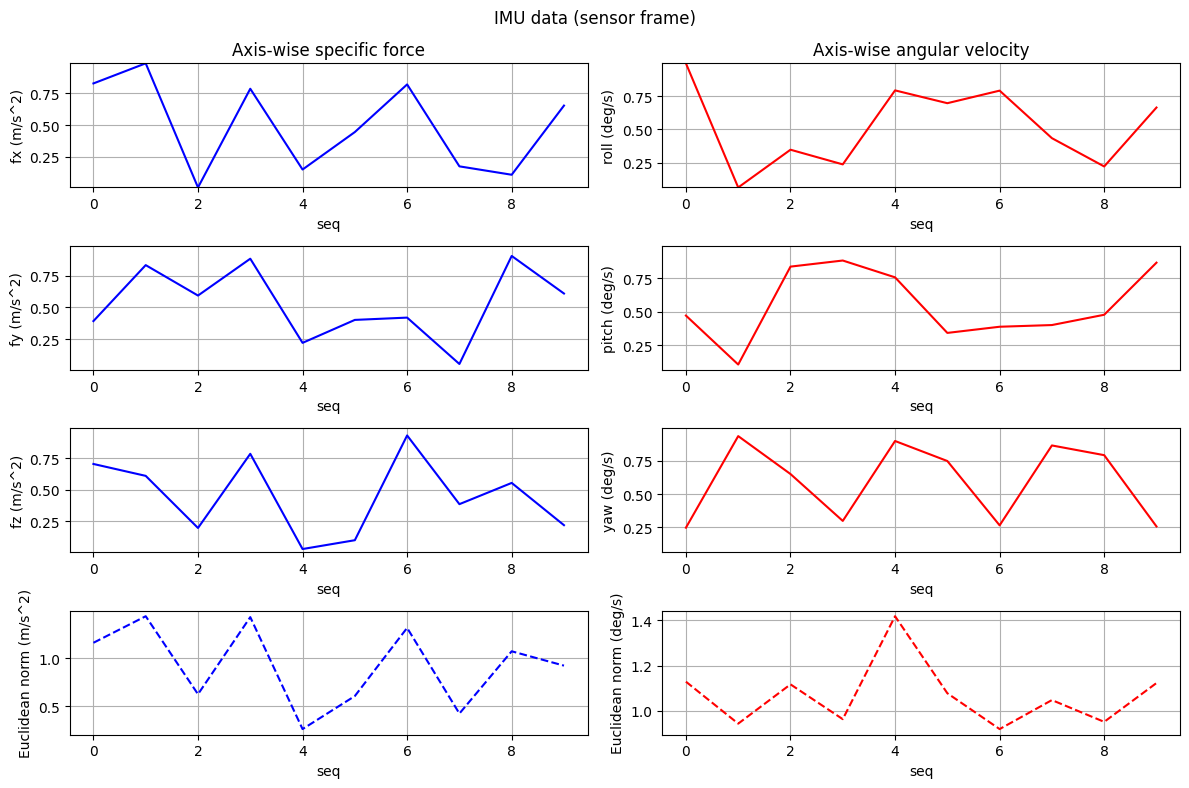

In [ ]:
plotRawData(seq, a, w)